# ENTRENAMIENTO DE MODELOS
---

### Clasificación de galaxias según su morfología

#### Integrantes

- `Crespo Neri, Diego Ubaldo` (`ubaldo.crespo@iteso.mx`)
- `Garibay Zepeda, Julio Andrés` (`julio.garibay@iteso.mx`)
- `Vázquez Sandoval, Isaac Ernesto` (`isaac.vazquez@iteso.mx`)

---
---

### Bibliotecas

In [101]:
# Básicas
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from sklearn.metrics import (accuracy_score, auc, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted

In [102]:
# NN
import keras_tuner as kt
import tensorflow as tf
from keras.callbacks import EarlyStopping
from keras.layers import (BatchNormalization, Conv2D, Dense, Dropout, Flatten,
                          Input, MaxPooling2D, ReLU)
from keras.models import Sequential
from keras.optimizers import Adam
from keras.regularizers import l2

In [60]:
# SV
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [61]:
# LR
from sklearn.linear_model import LogisticRegression

In [62]:
# Swag
style = "/home/toutl/code/.machine.mplstyle"
if os.path.exists(style):
    plt.style.use(style)

In [63]:
# Stablish seeds
SEED = 35

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Para keras
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

---
---

### Data:

##### 1. Lectura de los datos

In [64]:
# Paths de las carpetas donde se encuentran los datos
data_folder = Path("../../data/classification/")
processed_folder = data_folder / "processed"

In [65]:
# Leemos la metadata (etiquetas e ids)
metadata_df = pd.read_csv(processed_folder / "sample_64x64_10570.csv").astype(str)
display(metadata_df.head())

,image_id,class
0,110581,0
1,53890,0
2,268229,0
3,69751,0
4,294591,0


In [66]:
# Cargamos las imágenes procesadas
processed_images = np.load(processed_folder / "sample_64x64_10570.npz")
files = processed_images.files
print(files[:10])
print(len(files))

['110581', '53890', '268229', '69751', '294591', '287069', '58579', '49874', '17922', '7030']
10570


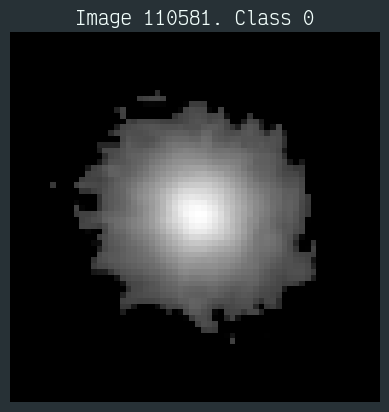

In [67]:
# Ejemplo de uso de una imágen
img_name = files[0]
idx = metadata_df.index[metadata_df["image_id"] == img_name][0]
img_class = metadata_df.at[idx, "class"]

plt.imshow(processed_images[img_name], cmap="gray")
plt.title(f"Image {img_name}. Class {img_class}")
plt.axis("off")
plt.show()

In [68]:
# Obtenemos un arreglo con todas las imágenes
images_ids = metadata_df["image_id"].to_list()

images_array = np.empty((len(metadata_df), 64, 64), dtype=np.float32)

for i, img_name in enumerate(images_ids):
    image = processed_images[img_name]

    # Asegurarse que las imágenes estén normalizadas
    if image.max() > 1 or image.min() < 0:
        raise ValueError(f"Image {img_name} not normalized.")

    images_array[i] = image

In [69]:
# Revisando la cantidad de etiquetas respecto a la cantidad de imágenes, y congruencia de tamaños
print(images_array.shape, metadata_df["class"].shape)

(10570, 64, 64) (10570,)


---

##### 2. Separación de datos en entrenamiento y prueba

In [70]:
# Objeto que encapsule los datos
class Data:
    def __init__(self, X, y, random_state=SEED):
        # Splits
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=random_state, stratify=y
        )
        x_train, x_valid, y_train, y_valid = train_test_split(
            x_train, y_train, test_size=0.2, random_state=random_state, stratify=y_train
        )

        # Agregar canal
        self.X_train = x_train[..., None]
        self.X_valid = x_valid[..., None]
        self.X_test = x_test[..., None]

        self.y_train = np.asarray(y_train)
        self.y_valid = np.asarray(y_valid)
        self.y_test = np.asarray(y_test)

        # Validar shapes
        assert self.X_train.shape[1:] == (64, 64, 1), "Unexpected image shape"
        assert len(self.X_train) == len(self.y_train), "Train feature/label mismatch"
        assert len(self.X_valid) == len(self.y_valid), "Valid feature/label mismatch"
        assert len(self.X_test) == len(self.y_test), "Test feature/label mismatch"

        # Validar labels
        unique_labels = np.unique(y)
        assert set(unique_labels) <= {0, 1}, f"Unexpected labels found: {unique_labels}"

    # Crear versiones planas
    def _flatten(self, X):
        return X.reshape(len(X), -1)

    @property
    def X_train_flat(self):
        return self._flatten(self.X_train)

    @property
    def X_valid_flat(self):
        return self._flatten(self.X_valid)

    @property
    def X_test_flat(self):
        return self._flatten(self.X_test)

In [71]:
# Se genera el objeto para los datos
data = Data(
    X=images_array.astype("float32"),
    y=metadata_df["class"].astype("int8"),
)

In [72]:
# Checar
display(data.X_test_flat.shape)

(2114, 4096)

---
---

### Modelos:

#### Introducción

El primer objetivo a probar será comparar 4 modelos sencillos para una clasificación de imágenes de galaxias como se ha estado trabajando.

La clasificaición será binaria siendo...
- `0`: S, galaxias con forma espiral.
- `1`: E, morfología elíptica.

Recordando que como outliers de la clasificación se consideran otros Artefactos u Objetos distintos a galaxias.

Los modelos a utilizar serán 4:

- **CNN** (Red Neuronal Convolucional): 
    - Es la favorita. El estado del arte para imágenes.
    - Representa un sistema visual, capaz de detectar bordes, texturas y formas.
    - Aprende patrones complejos a costa de una gran cantidad de imágenes.

- **MLP** (Perceptrón MultiCapa): 
    - Generaliza más que una CNN, tiene ceguera ante la espacialidad.
    - Util cuando no hay linealidad.
    - No es realmente utilizada para imágenes.

- **SVC** (Clasificador de Soporte Vectorial): 
    - No entiende espacialidad ni la estructura de las imágenes.
    - Bueno para decisiones de frontera.
    - No muy amigable con conjuntos de datos grandes.

- **LR** (Regresión Logística): 
    - Útil como base, para reconocer la necesidad de linealidad o estructuras complejas.
    - Bueno para establecer fronteras.

Las métricas consideradas para evaluar dichos modelos, deberán ser congruentes para el problema, una clasificación binaria.

Por lo tanto se utilizarán:

- Accuracy:
  - Indica la proporción de aciertos.
  - Podría cargar un ligero sesgo debido al que las clases tinene un balance de `60:40`, por esto mismo se complementa con otras métricas.

- Precision, Recall y F1-score:
  - Muestran el comportamiento del modelo con cada clase.
  - El F1 combina precisión y recall en un solo número.

- ROC–AUC:
  - Mide la capacidad del modelo para separar las dos clases.

La estructura del programa es la siguiente:
1. Se cargan los datos y separan en conjuntos de entrenamiento, validación y prueba.
2. Se entrenará una instancia sencilla de cada modelo.
    - Luego se compararán en bruto.
3. Con técnicas de ajuste de hiperparámetros se buscarán mejores versiones de cada modelo.
    - Y una comparación se realizará con los que obtengan las mejores métricas de cada uno.
4. Finalmente, se entrenará el mejor modelo que se haya obtenido con los datos sobrantes del muestreo y con la totalidad de los obtenidos.

---

#### Básicos
---

##### 1. CNN

In [73]:
def visualize_training(hist):
    plt.plot(hist.history["accuracy"])
    plt.plot(hist.history["val_accuracy"])
    plt.title("accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.ylim((0, 1))
    plt.xlim((0, 20))
    plt.legend(["training", "validation"], loc="lower right")
    plt.show()

    # training vs validation loss
    plt.plot(hist.history["loss"])
    plt.plot(hist.history["val_loss"])
    plt.title("loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")
    plt.ylim((0, 1))
    plt.xlim((0, 20))
    plt.legend(["training", "validation"], loc="upper right")
    plt.show()

In [74]:
def build_binary_cnn(data):
    model = Sequential()

    model.add(Input(shape=data.X_train.shape[1:]))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=32, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=128, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Dropout(0.2))
    model.add(Flatten())

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    optimizer = Adam(learning_rate=3e-4)
    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizer,  # type: ignore
        metrics=["accuracy", "AUC"],
    )

    return model

In [75]:
# Callbacks para el fit del modelo, funcionan para encontrar el mejor epoch
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [76]:
cnn_model = build_binary_cnn(data)
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_13 (ReLU)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 365,857 (1.40 MB)

 Trainable params: 365,089 (1.39 MB)

 Non-trainable params: 768 (3.00 KB)

In [77]:
hist_cnn = cnn_model.fit(
    data.X_train,
    data.y_train,
    batch_size=32,
    epochs=20,
    validation_data=(data.X_valid, data.y_valid),
    callbacks=[early_stop],
)

Epoch 1/20


2025-11-21 19:04:14.810960: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


211/212 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - AUC: 0.7158 - accuracy: 0.6762 - loss: 0.6386

2025-11-21 19:04:35.277613: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - AUC: 0.7356 - accuracy: 0.6904 - loss: 0.6231 - val_AUC: 0.4096 - val_accuracy: 0.5881 - val_loss: 1.5655
Epoch 2/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - AUC: 0.7876 - accuracy: 0.7266 - loss: 0.5575 - val_AUC: 0.7751 - val_accuracy: 0.5881 - val_loss: 1.5198
Epoch 3/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - AUC: 0.8038 - accuracy: 0.7398 - loss: 0.5386 - val_AUC: 0.8212 - val_accuracy: 0.7051 - val_loss: 0.5985
Epoch 4/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 96ms/step - AUC: 0.8198 - accuracy: 0.7525 - loss: 0.5170 - val_AUC: 0.8480 - val_accuracy: 0.7358 - val_loss: 0.5435
Epoch 5/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 20s 92ms/step - AUC: 0.8334 - accuracy: 0.7602 - loss: 0.4971 - val_AUC: 0.8574 - val_accuracy: 0.7902 - val_loss: 0.4795
Epoch 6/20
212/212 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - AUC: 0.8499 - accuracy: 0.7759 - loss: 0.4747 - val_AUC: 0.8597 - val_accuracy: 0.7547 - val_loss: 0.5115
Epoch 7/20
212/212 ━━━━━━━━━━━━━━━━━━━

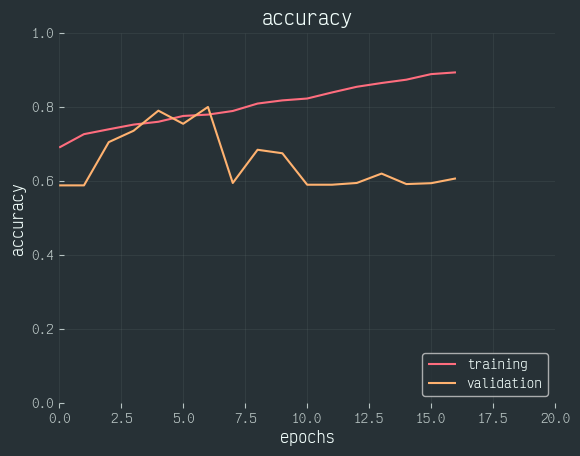

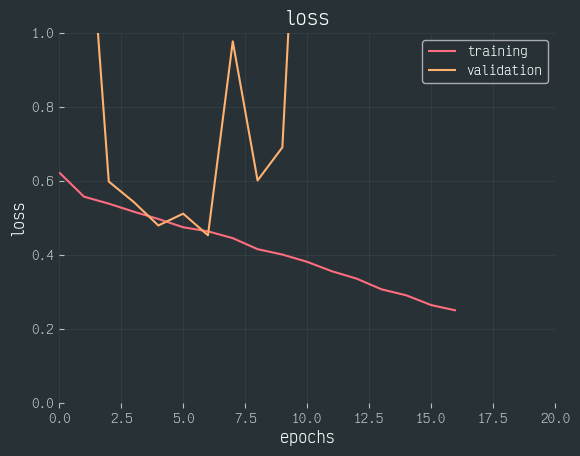

2025-11-21 19:09:55.112488: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Accuracy CNN: 74.88%


In [78]:
visualize_training(hist_cnn)

score_cnn = cnn_model.evaluate(data.X_test, data.y_test, verbose="0")
print(f"Accuracy CNN: {score_cnn[1] * 100:.2f}%")

---

##### 2. MLP

In [79]:
def build_binary_mlp(data: Data):
    model = Sequential()

    model.add(Input(shape=data.X_train.shape[1:]))
    model.add(Flatten())

    model.add(Dense(256, activation="relu", kernel_regularizer=l2(1e-4)))
    model.add(Dropout(0.3))

    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(3e-4),  # type: ignore
        metrics=["accuracy", "AUC"],
    )

    return model

In [80]:
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [81]:
mlp_model = build_binary_mlp(data)
mlp_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,081,857 (4.13 MB)

 Trainable params: 1,081,857 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
hist_mlp = mlp_model.fit(
    data.X_train,
    data.y_train,
    batch_size=32,
    epochs=40,
    validation_data=(data.X_valid, data.y_valid),
    callbacks=[early_stop],
)

Epoch 1/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - AUC: 0.5312 - accuracy: 0.5735 - loss: 0.7238 - val_AUC: 0.5961 - val_accuracy: 0.5875 - val_loss: 0.6952
Epoch 2/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - AUC: 0.5893 - accuracy: 0.5874 - loss: 0.6982 - val_AUC: 0.6408 - val_accuracy: 0.5875 - val_loss: 0.6795
Epoch 3/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6066 - accuracy: 0.5930 - loss: 0.6878 - val_AUC: 0.6430 - val_accuracy: 0.5875 - val_loss: 0.6781
Epoch 4/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - AUC: 0.6256 - accuracy: 0.6056 - loss: 0.6762 - val_AUC: 0.6858 - val_accuracy: 0.5957 - val_loss: 0.6611
Epoch 5/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6432 - accuracy: 0.6169 - loss: 0.6700 - val_AUC: 0.7120 - val_accuracy: 0.5940 - val_loss: 0.6557
Epoch 6/40
212/212 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - AUC: 0.6594 - accuracy: 0.6345 - loss: 0.6593 - val_AUC: 0.7194 - val_accuracy: 0.6566 - val_loss: 0.6471
Epoch 7/40
212/212 ━━━━━━━━━━━━━━━━

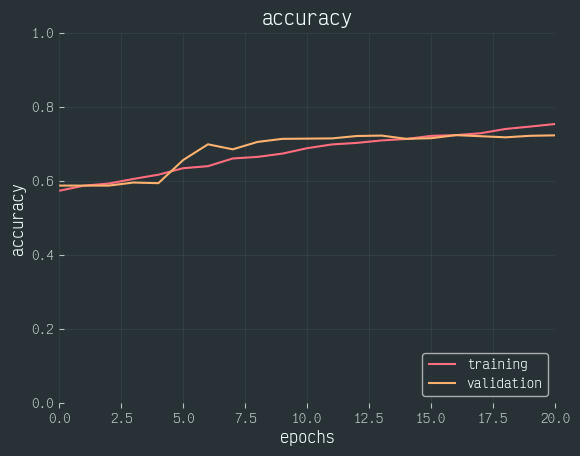

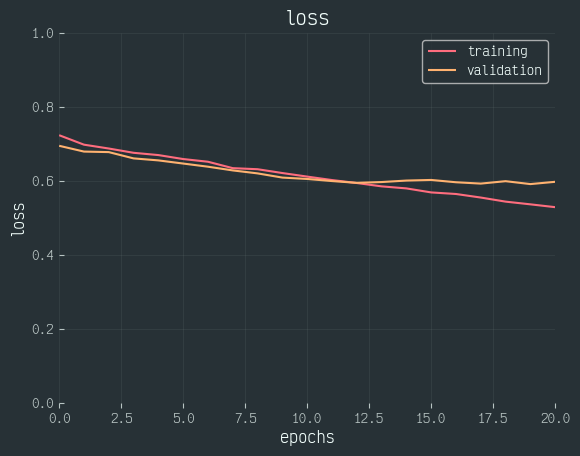

Accuracy MLP: 70.06%


2025-11-21 19:11:00.385637: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [83]:
visualize_training(hist_mlp)

score_mlp = mlp_model.evaluate(data.X_test, data.y_test, verbose="0")
print(f"Accuracy MLP: {score_mlp[1] * 100:.2f}%")

---

##### 3. Support Vector Classifier

In [84]:
svc_model = SVC(kernel="rbf", C=5, gamma=0.001, class_weight="balanced")

svc_model.fit(data.X_train_flat, data.y_train)

,C,5
,kernel,'rbf'
,degree,3
,gamma,0.001
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [85]:
y_pred = svc_model.predict(data.X_valid_flat)
print(classification_report(data.y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.68      0.74       995
           1       0.63      0.78      0.70       697

    accuracy                           0.72      1692
   macro avg       0.73      0.73      0.72      1692
weighted avg       0.74      0.72      0.73      1692



---

##### 4. Logistic Regression

In [86]:
logreg_model = LogisticRegression(max_iter=200, solver="liblinear")
logreg_model.fit(data.X_train_flat, data.y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,200
,multi_class,'deprecated'


In [87]:
y_pred = logreg_model.predict(data.X_valid_flat)
print(classification_report(data.y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.75      0.73       995
           1       0.61      0.56      0.58       697

    accuracy                           0.67      1692
   macro avg       0.66      0.65      0.66      1692
weighted avg       0.67      0.67      0.67      1692



---

##### - Métricas

In [94]:
def get_scores(model, data, split="test", threshold=0.5):
    X = getattr(data, f"X_{split}")
    X_flat = getattr(data, f"X_{split}_flat")

    if "keras" in str(type(model)).lower():
        y_score = model.predict(X, verbose=0).reshape(-1)
        y_pred = (y_score >= threshold).astype(int)
        return y_score, y_pred

    if hasattr(model, "decision_function"):
        y_score = model.decision_function(X_flat)
        y_pred = (y_score >= threshold).astype(int)
        return y_score, y_pred

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_flat)[:, 1]
        y_pred = (y_score >= threshold).astype(int)
        return y_score, y_pred

    y_pred = model.predict(X_flat)
    return None, y_pred

In [95]:
def visualize_metrics(models, data, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0, 1, 200)

    plt.figure(figsize=(16, 5))

    # 1. ROC Curve
    plt.subplot(1, 3, 1)
    for name, model in models.items():

        y_score, _ = get_scores(model, data)

        if y_score is None:
            continue

        fpr, tpr, _ = roc_curve(data.y_test, y_score)
        model_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={model_auc:.3f})")

    plt.plot([0, 1], [0, 1], "w--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    # 2. Precision–Recall Curve
    plt.subplot(1, 3, 2)
    for name, model in models.items():

        y_score, _ = get_scores(model, data)

        if y_score is None:
            continue

        precision, recall, _ = precision_recall_curve(data.y_test, y_score)
        plt.plot(recall, precision, label=name)

    plt.title("Precision–Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    # 3. F1 vs Threshold
    plt.subplot(1, 3, 3)
    for name, model in models.items():

        y_score, _ = get_scores(model, data)

        if y_score is None:
            continue

        f1_scores = []
        for t in thresholds:
            y_pred = (y_score >= t).astype(int)
            f1_scores.append(f1_score(data.y_test, y_pred, zero_division=0))

        plt.plot(thresholds, f1_scores, label=name)

    plt.title("F1 vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [96]:
def evaluate_models(models: dict, data: Data, threshold=0.5):
    results = []

    for name, model in models.items():

        # Predicción
        start = time.time()

        if hasattr(model, "predict") and "keras" in str(type(model)).lower():
            y_prob = model.predict(data.X_test, verbose=0).reshape(-1)
            y_pred = (y_prob >= threshold).astype(int)

        else:
            check_is_fitted(model)

            if hasattr(model, "decision_function"):
                y_prob = model.decision_function(data.X_test_flat)
                y_pred = model.predict(data.X_test_flat)

            elif hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(data.X_test_flat)[:, 1]
                y_pred = model.predict(data.X_test_flat)

            else:
                y_prob = None
                y_pred = model.predict(data.X_test_flat)

        runtime = time.time() - start

        # Métricas
        acc = accuracy_score(data.y_test, y_pred)
        prec = precision_score(data.y_test, y_pred, zero_division=0)
        rec = recall_score(data.y_test, y_pred, zero_division=0)
        f1 = f1_score(data.y_test, y_pred, zero_division=0)

        # ROC–AUC si hay probabilidades
        if y_prob is not None:
            try:
                auc = roc_auc_score(data.y_test, y_prob)
            except ValueError:
                auc = np.nan
        else:
            auc = np.nan

        # Complejidad aprox (número de parámetros)
        if hasattr(model, "count_params"):
            params = model.count_params()
        elif hasattr(model, "coef_"):
            params = model.coef_.size + model.intercept_.size
        elif "svc" in name:
            params = model.support_vectors_.shape[0]
        else:
            params = np.nan

        results.append(
            {
                "Modelo": name,
                "Accuracy": acc,
                "Precision": prec,
                "Recall": rec,
                "F1": f1,
                "ROC-AUC": auc,
                "Parámetros": params,
                "Tiempo_inferencia_s": runtime,
            }
        )

    return pd.DataFrame(results)

In [97]:
def plot_confusion_matrices(models, data, threshold=0.5):
    n = len(models)
    plt.figure(figsize=(4 * n, 4))

    for i, (name, model) in enumerate(models.items(), 1):
        _, y_pred = get_scores(model, data, threshold=threshold)
        cm = confusion_matrix(data.y_test, y_pred)

        plt.subplot(1, n, i)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")

    plt.tight_layout()
    plt.show()

In [98]:
basic_models = {
    "cnn": cnn_model,
    "mlp": mlp_model,
    "svc": svc_model,
    "logreg": logreg_model,
}

2025-11-21 19:16:39.667269: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2025-11-21 19:17:05.549291: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),

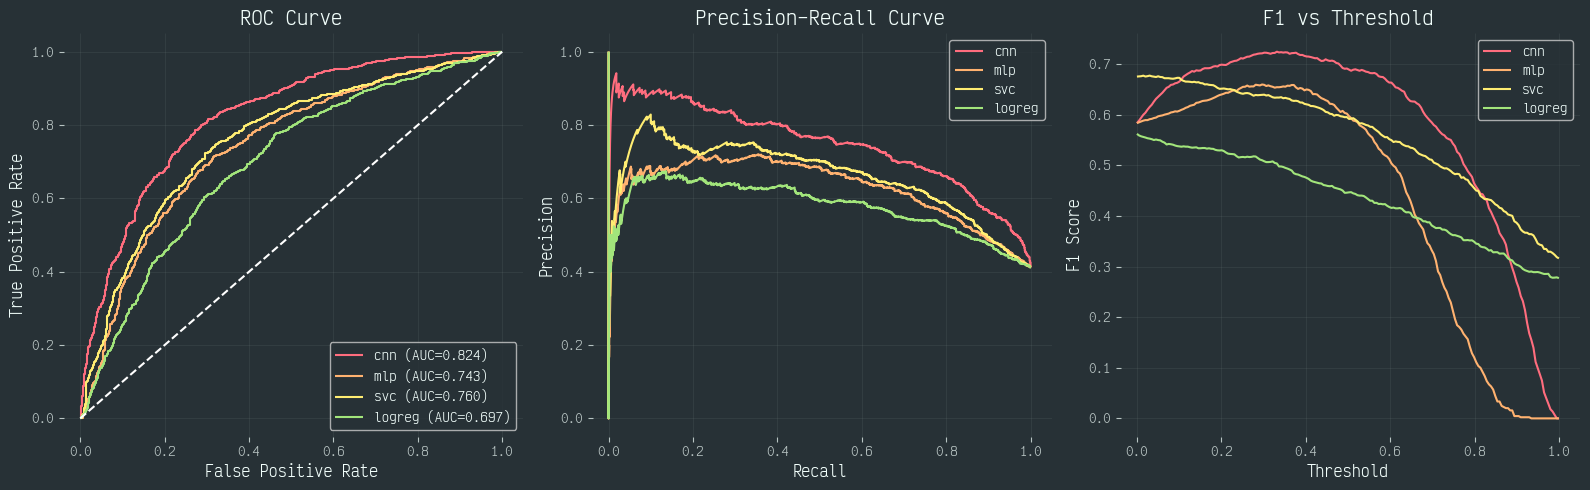

2025-11-21 19:17:58.549204: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC,Parámetros,Tiempo_inferencia_s
0,cnn,0.75,0.67,0.76,0.71,0.82,365857,1.22
1,mlp,0.70,0.63,0.68,0.65,0.74,1081857,0.20
2,svc,0.70,0.61,0.76,0.68,0.76,5129,44.54
3,logreg,0.66,0.59,0.54,0.56,0.70,4097,0.04


In [99]:
visualize_metrics(models=basic_models, data=data)

results = evaluate_models(models=basic_models, data=data, threshold=0.4)
results.round(2)

2025-11-21 19:19:44.571744: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


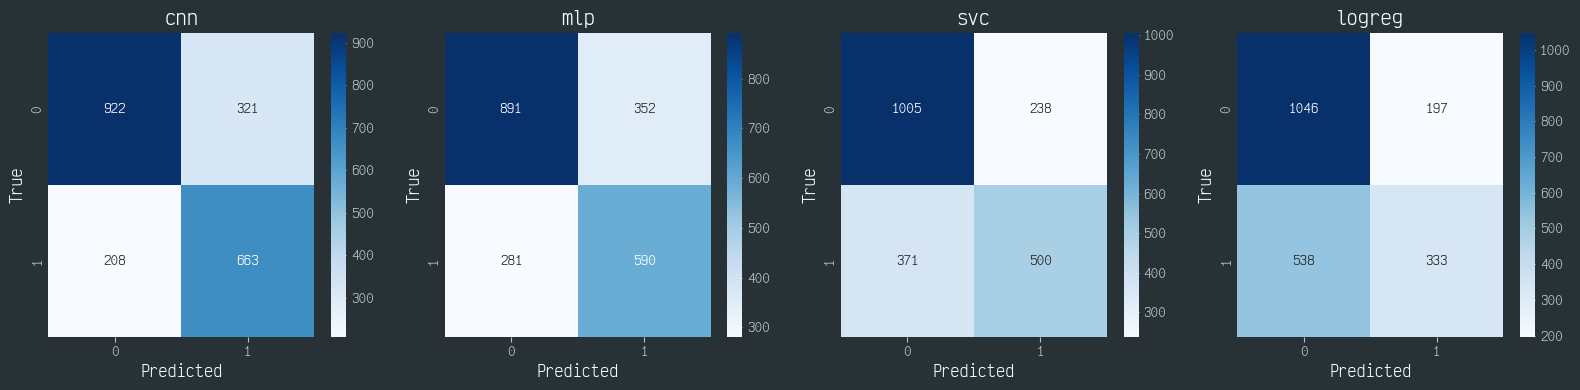

In [103]:
plot_confusion_matrices(basic_models, data, threshold=0.4)

**Algunas conclusiones:**

- 

-

#### Con ajuste de hiper-parámetros
---

##### 1. CNN

In [ ]:
def build_cnn_model(hp):
    model = Sequential()

    # HP
    f = hp.Choice("filters", [64, 128])
    d = hp.Choice("dropout", [0.3, 0.4])
    lr = hp.Choice("lr", [1e-4, 1e-3])

    model.add(Input(shape=data.X_train.shape[1:]))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=64, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=f, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Conv2D(filters=128, kernel_size=3, padding="same"))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(MaxPooling2D(pool_size=2))

    model.add(Dropout(f))
    model.add(Flatten())

    model.add(Dense(128))
    model.add(BatchNormalization())
    model.add(ReLU())
    model.add(Dropout(0.3))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=lr),  # type: ignore
        metrics=["accuracy", "AUC"],
    )

    return model

In [ ]:
cnn_tuner = kt.RandomSearch(
    build_cnn_model,
    objective="val_accuracy",
    max_trials=10,
    directory="cnn_tuning",
    project_name="cnn_binary",
)

cnn_tuner.search(
    data.X_train, data.y_train, validation_data=(data.X_valid, data.y_valid), epochs=10
)

---

##### 2. MLP

In [ ]:
def build_mlp_model(hp):
    model = Sequential()

    # HP
    u = hp.Choice("units", [128, 256])
    d = hp.Choice("dropout1", [0.3, 0.4])
    lr = hp.Choice("lr", [1e-4, 1e-3])

    model.add(Input(shape=data.X_train.shape[1:]))
    model.add(Flatten())

    model.add(Dense(units=u, activation="relu"))
    model.add(Dropout(0.3))

    model.add(Dense(units=u / 2, activation="relu"))
    model.add(Dropout(d))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        loss="binary_crossentropy",
        optimizer=Adam(learning_rate=lr),  # type: ignore
        metrics=["accuracy"],
    )

    return model

In [ ]:
mlp_tuner = kt.RandomSearch(
    build_mlp_model,
    objective="val_accuracy",
    max_trials=10,
    directory="mlp_tuning",
    project_name="cnn_binary",
)

mlp_tuner.search(
    data.X_train, data.y_train, validation_data=(data.X_valid, data.y_valid), epochs=10
)

---

##### 3. Support Vector Classifier

In [ ]:
svc_pipe = Pipeline(
    [
        ("pca", PCA(n_components=0.85, whiten=True, random_state=35)),
        ("svc", SVC(class_weight="balanced", kernel="rbf", probability=True)),
    ]
)

param_grid = {
    "svc__C": [5],  # previas iteraciones nos indicaron este valor
    "svc__gamma": [0.0011, 0.0012, 0.00013],
}

svc_grid = GridSearchCV(svc_pipe, param_grid, scoring="roc_auc", verbose=2, n_jobs=-1)

svc_grid.fit(data.X_train_flat, data.y_train)

In [ ]:
print(f"Best Params: {svc_grid.best_params_}")
print(f"Best Cross-Val AUC: {svc_grid.best_score_:.4f}")

In [ ]:
y_pred = svc_grid.predict(data.X_test_flat)
y_proba = svc_grid.predict_proba(data.X_test_flat)[:, 1]

print(classification_report(data.y_test, y_pred))

print(f"\nTest Set ROC AUC: {roc_auc_score(data.y_test, y_proba):.4f}")

---

##### 4. Logistic Regression

In [ ]:
logreg_pipe = Pipeline(
    [
        ("pca", PCA(random_state=35)),
        ("logreg", LogisticRegression(solver="liblinear", max_iter=1000)),
    ]
)

param_grid = {
    "pca__n_components": [50, 100, 150, 200],
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__penalty": ["l1", "l2"],
}

logreg_grid = GridSearchCV(
    logreg_pipe, param_grid, cv=5, scoring="roc_auc", n_jobs=-1, verbose=2
)

logreg_grid.fit(data.X_train_flat, data.y_train)

In [ ]:
print(f"Best Params: {logreg_grid.best_params_}\n")

y_pred = logreg_grid.predict(data.X_test_flat)
print(classification_report(data.y_test, y_pred))

---
---

### Conclusiones